# Hotel Booking Cancellation Prediction using Logistic Regression
**Dataset:** Hotel Reservations Dataset  
**Source:** https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset  
**Target Variable:** `booking_status` (0 = Not Cancelled, 1 = Cancelled)  
**Task Type:** Binary Classification  
**Author:** Manoj Kumar Sithrama Reddy

## 1. Import Libraries

In [32]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split

%matplotlib inline
print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load and Explore the Dataset

In [33]:
df = pd.read_csv('Hotel Reservations.csv')
print('Dataset Shape:', df.shape)
print('\nColumn Names and Data Types:')
df.info()

Dataset Shape: (36275, 19)

Column Names and Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  str    
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  str    
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  str    
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                       

In [34]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [35]:
df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [36]:
print('Missing Values per Column:')
print(df.isnull().sum())
print('\nTotal missing values:', df.isnull().sum().sum())

Missing Values per Column:
Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

Total missing values: 0


In [37]:
print('Target Variable Distribution:')
print(df['booking_status'].value_counts())
print('\nPercentage:')
print(round(df['booking_status'].value_counts(normalize=True) * 100, 2))

Target Variable Distribution:
booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64

Percentage:
booking_status
Not_Canceled    67.24
Canceled        32.76
Name: proportion, dtype: float64


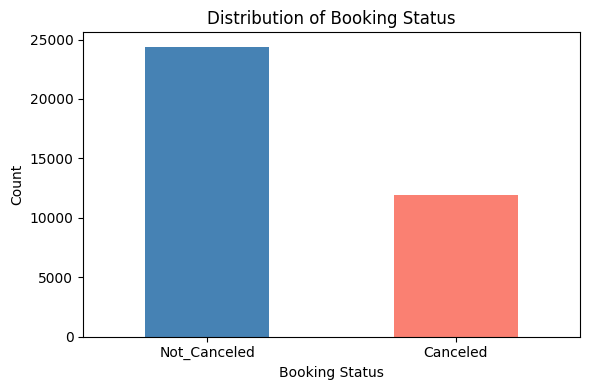

In [38]:
plt.figure(figsize=(6, 4))
df['booking_status'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Distribution of Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [39]:
# Drop Booking_ID (just an identifier, not a feature)
if 'Booking_ID' in df.columns:
    df = df.drop(columns=['Booking_ID'])
    print('Booking_ID dropped. New shape:', df.shape)

Booking_ID dropped. New shape: (36275, 18)


In [40]:
# Encode target: Canceled=1, Not_Canceled=0
df['booking_status'] = df['booking_status'].map({'Canceled': 1, 'Not_Canceled': 0})
print('Target encoded successfully.')
print(df['booking_status'].value_counts())

Target encoded successfully.
booking_status
0    24390
1    11885
Name: count, dtype: int64


## 4. Feature Engineering — Encode ALL Categorical Variables
**This section includes the fix for the ValueError about object dtype.**

In [41]:
# Separate features from target
X_features = [col for col in df.columns if col != 'booking_status']
Y = df['booking_status'].astype(float)

# One-hot encode all categorical columns
encoded_df = pd.get_dummies(df[X_features], drop_first=True)

# FIX 1: Convert boolean columns to int (True/False -> 1/0)
bool_cols = encoded_df.select_dtypes(include='bool').columns
encoded_df[bool_cols] = encoded_df[bool_cols].astype(int)

# FIX 2: Force all remaining columns to numeric
encoded_df = encoded_df.apply(pd.to_numeric, errors='coerce')

# FIX 3: Drop any columns that became NaN (couldn't convert)
encoded_df = encoded_df.dropna(axis=1)

# FIX 4: Final cast to float64
encoded_df = encoded_df.astype(float)

print('Shape after encoding:', encoded_df.shape)
print('All dtypes numeric:', (encoded_df.dtypes != object).all())
print('Remaining object columns:', list(encoded_df.select_dtypes(include='object').columns))

Shape after encoding: (36275, 27)
All dtypes numeric: True
Remaining object columns: []


## 5. Prepare Data for Modeling

In [42]:
# Add intercept constant
X = sm.add_constant(encoded_df).astype(float)

print('X shape:', X.shape)
print('Y shape:', Y.shape)

X shape: (36275, 28)
Y shape: (36275,)


In [43]:
# 70% train, 30% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)
print('Training samples:', X_train.shape[0])
print('Test samples    :', X_test.shape[0])

Training samples: 25392
Test samples    : 10883


## 6. Build Full Logistic Regression Model

In [44]:
logit = sm.Logit(y_train, X_train)
logit_model = logit.fit(max_iter=300, disp=False)
print('Full model trained successfully!')

C:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: max_iter. After release 0.14, this will raise.
  warnings.warn(
C:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Full model trained successfully!


In [45]:
logit_model.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                                  Results: Logit
==================================================================================================================
Model:                               Logit                            Method:                           MLE       
Dependent Variable:                  booking_status                   Pseudo R-squared:                 0.327     
Date:                                2026-05-03 22:52                 AIC:                              21621.8905
No. Observations:                    25392                            BIC:                              21849.8718
Df Model:                            27                               Log-Likelihood:                   -10783.   
Df Residuals:                        25364                            LL-Null:                          -16030.   
Converged:                           0.0000                           LLR p-value:                      0.0000    
No. Iterations:                      35.0000                          Scale:                            1.0000    
------------------------------------------------------------------------------------------------------------------
                                       Coef.       Std.Err.        z     P>|z|        [0.025           0.975]     
------------------------------------------------------------------------------------------------------------------
const                                -836.8666         120.1052  -6.9678 0.0000        -1072.2684        -601.4648
no_of_adults                            0.1216           0.0376   3.2309 0.0012            0.0478           0.1953
no_of_children                          0.1068           0.0594   1.7993 0.0720           -0.0095           0.2231
no_of_weekend_nights                    0.1208           0.0198   6.0950 0.0000            0.0820           0.1597
no_of_week_nights                       0.0320           0.0123   2.6006 0.0093            0.0079           0.0562
required_car_parking_space             -1.6991           0.1424 -11.9323 0.0000           -1.9782          -1.4200
lead_time                               0.0155           0.0003  58.3725 0.0000            0.0149           0.0160
arrival_year                            0.4133           0.0595   6.9446 0.0000            0.2967           0.5300
arrival_month                          -0.0428           0.0065  -6.5917 0.0000           -0.0556          -0.0301
arrival_date                            0.0026           0.0019   1.3259 0.1849           -0.0012           0.0064
repeated_guest                         -2.5717           0.6581  -3.9080 0.0001           -3.8615          -1.2819
no_of_previous_cancellations            0.2662           0.0776   3.4310 0.0006            0.1141           0.4183
no_of_previous_bookings_not_canceled   -0.0711           0.0885  -0.8033 0.4218           -0.2446           0.1024
avg_price_per_room                      0.0186           0.0007  25.3133 0.0000            0.0172           0.0201
no_of_special_requests                 -1.4858           0.0303 -49.0961 0.0000           -1.5451          -1.4265
type_of_meal_plan_Meal Plan 2           0.1778           0.0662   2.6871 0.0072            0.0481           0.3075
type_of_meal_plan_Meal Plan 3          35.3330    33554432.0000   0.0000 1.0000    -65765442.9087    65765513.5747
type_of_meal_plan_Not Selected          0.1922           0.0532   3.6149 0.0003            0.0880           0.2964
room_type_reserved_Room_Type 2         -0.4339           0.1305  -3.3246 0.0009           -0.6897          -0.1781
room_type_reserved_Room_Type 3          1.1026           1.9871   0.5549 0.5790           -2.7921           4.9972
room_type_reserved_Room_Type 4         -0.2854           0.0531  -5.3697 0.0000           -0.3896          -0.1812
room_type_reserved_Room_Type 5         -0.6859           0.2073  -3.3093 0.0009           -

## 7. Feature Selection — Significant Variables (p ≤ 0.05)

In [46]:
def get_significant_vars(lm, threshold=0.05):
    var_p_vals_df = pd.DataFrame(lm.pvalues)
    var_p_vals_df['vars'] = var_p_vals_df.index
    var_p_vals_df.columns = ['pvals', 'vars']
    return list(var_p_vals_df[var_p_vals_df.pvals <= threshold]['vars'])

significant_vars = get_significant_vars(logit_model)
print(f'Significant variables: {len(significant_vars)}')
for v in significant_vars:
    print(' -', v)

Significant variables: 21
 - const
 - no_of_adults
 - no_of_weekend_nights
 - no_of_week_nights
 - required_car_parking_space
 - lead_time
 - arrival_year
 - arrival_month
 - repeated_guest
 - no_of_previous_cancellations
 - avg_price_per_room
 - no_of_special_requests
 - type_of_meal_plan_Meal Plan 2
 - type_of_meal_plan_Not Selected
 - room_type_reserved_Room_Type 2
 - room_type_reserved_Room_Type 4
 - room_type_reserved_Room_Type 5
 - room_type_reserved_Room_Type 6
 - room_type_reserved_Room_Type 7
 - market_segment_type_Corporate
 - market_segment_type_Offline


## 8. Build Final Model (Significant Variables Only)

In [47]:
final_logit = sm.Logit(
    y_train,
    sm.add_constant(X_train[significant_vars])
).fit(max_iter=300, disp=False)
print('Final model trained!')

Final model trained!


C:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: max_iter. After release 0.14, this will raise.
  warnings.warn(


In [48]:
final_logit.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                    Results: Logit
======================================================================================
Model:                     Logit                   Method:                  MLE       
Dependent Variable:        booking_status          Pseudo R-squared:        0.326     
Date:                      2026-05-03 22:52        AIC:                     21642.9772
No. Observations:          25392                   BIC:                     21813.9632
Df Model:                  20                      Log-Likelihood:          -10800.   
Df Residuals:              25371                   LL-Null:                 -16030.   
Converged:                 1.0000                  LLR p-value:             0.0000    
No. Iterations:            11.0000                 Scale:                   1.0000    
--------------------------------------------------------------------------------------
                                 Coef.   Std.Err.    z     P>|z|    [0.025     0.975] 
--------------------------------------------------------------------------------------
const                          -825.0606 119.7543  -6.8896 0.0000 -1059.7747 -590.3464
no_of_adults                      0.1164   0.0370   3.1441 0.0017     0.0438    0.1890
no_of_weekend_nights              0.1233   0.0198   6.2298 0.0000     0.0845    0.1621
no_of_week_nights                 0.0336   0.0123   2.7363 0.0062     0.0095    0.0577
required_car_parking_space       -1.7019   0.1423 -11.9581 0.0000    -1.9808   -1.4229
lead_time                         0.0155   0.0003  58.7686 0.0000     0.0150    0.0160
arrival_year                      0.4074   0.0593   6.8653 0.0000     0.2911    0.5238
arrival_month                    -0.0447   0.0065  -6.9074 0.0000    -0.0574   -0.0320
repeated_guest                   -2.8465   0.6124  -4.6482 0.0000    -4.0468   -1.6463
no_of_previous_cancellations      0.2577   0.0751   3.4322 0.0006     0.1106    0.4049
avg_price_per_room                0.0193   0.0007  26.8071 0.0000     0.0179    0.0207
no_of_special_requests           -1.4812   0.0302 -49.1119 0.0000    -1.5403   -1.4221
type_of_meal_plan_Meal Plan 2     0.1643   0.0661   2.4854 0.0129     0.0347    0.2938
type_of_meal_plan_Not Selected    0.1974   0.0529   3.7342 0.0002     0.0938    0.3010
room_type_reserved_Room_Type 2   -0.3709   0.1270  -2.9209 0.0035    -0.6198   -0.1220
room_type_reserved_Room_Type 4   -0.2988   0.0529  -5.6541 0.0000    -0.4024   -0.1952
room_type_reserved_Room_Type 5   -0.7041   0.2067  -3.4061 0.0007    -1.1093   -0.2990
room_type_reserved_Room_Type 6   -0.7948   0.1186  -6.7036 0.0000    -1.0271   -0.5624
room_type_reserved_Room_Type 7   -1.1979   0.2985  -4.0125 0.0001    -1.7830   -0.6128
market_segment_type_Corporate    -0.8011   0.1021  -7.8498 0.0000    -1.0011   -0.6011
market_segment_type_Offline      -1.7858   0.0516 -34.6017 0.0000    -1.8870   -1.6847
======================================================================================

"""

## 9. Predict on Test Data

In [49]:
y_pred_prob = final_logit.predict(sm.add_constant(X_test[significant_vars]))

y_pred_df = pd.DataFrame({
    'actual': y_test,
    'predicted_prob': y_pred_prob
})
y_pred_df['predicted'] = y_pred_df['predicted_prob'].map(lambda x: 1 if x > 0.5 else 0)

print('Sample predictions (10 rows):')
y_pred_df.sample(10, random_state=42)

Sample predictions (10 rows):


,actual,predicted_prob,predicted
32308,0.0,0.028284,0
8707,0.0,0.424323,0
10527,0.0,0.409986,0
18914,0.0,0.010561,0
4280,0.0,0.095381,0
16909,1.0,0.836952,1
14091,0.0,0.226217,0
17666,1.0,0.517084,1
32429,1.0,0.336250,0
17656,1.0,0.358040,0


## 10. Model Evaluation

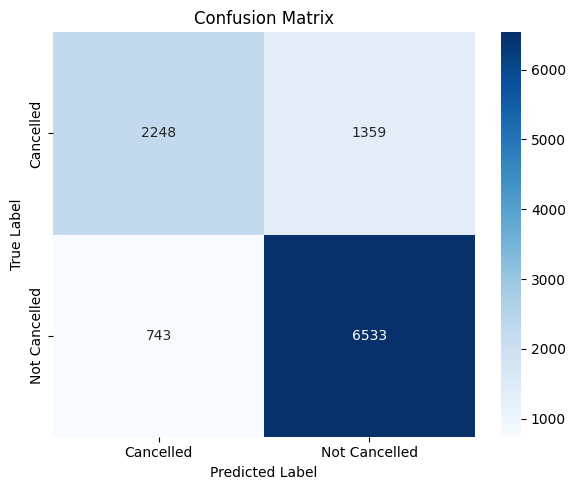

In [50]:
# Confusion Matrix
cm = metrics.confusion_matrix(y_pred_df['actual'], y_pred_df['predicted'], labels=[1, 0])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Cancelled', 'Not Cancelled'],
            yticklabels=['Cancelled', 'Not Cancelled'],
            cmap='Blues')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [51]:
# Accuracy
accuracy = metrics.accuracy_score(y_pred_df['actual'], y_pred_df['predicted'])
print(f'Model Accuracy: {accuracy * 100:.2f}%')

Model Accuracy: 80.69%


In [52]:
# Classification Report
print('Classification Report:')
print(metrics.classification_report(
    y_pred_df['actual'], y_pred_df['predicted'],
    target_names=['Not Cancelled', 'Cancelled']
))

Classification Report:
               precision    recall  f1-score   support

Not Cancelled       0.83      0.90      0.86      7276
    Cancelled       0.75      0.62      0.68      3607

     accuracy                           0.81     10883
    macro avg       0.79      0.76      0.77     10883
 weighted avg       0.80      0.81      0.80     10883



ROC-AUC Score: 0.8647


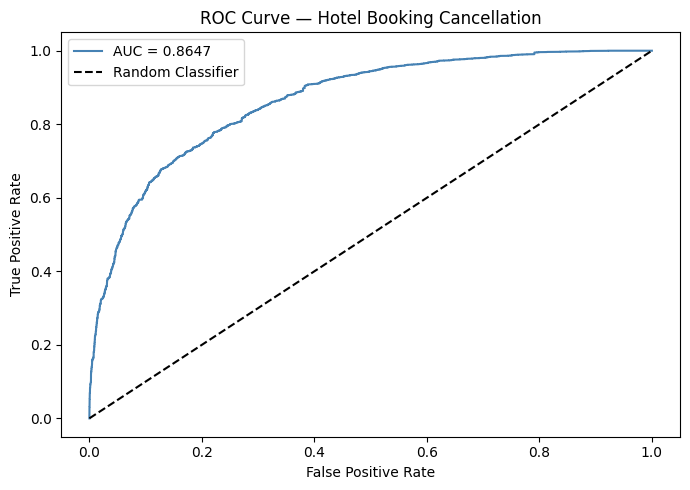

In [53]:
# ROC-AUC
auc = metrics.roc_auc_score(y_pred_df['actual'], y_pred_df['predicted_prob'])
print(f'ROC-AUC Score: {auc:.4f}')

fpr, tpr, _ = metrics.roc_curve(y_pred_df['actual'], y_pred_df['predicted_prob'])
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Hotel Booking Cancellation')
plt.legend()
plt.tight_layout()
plt.show()

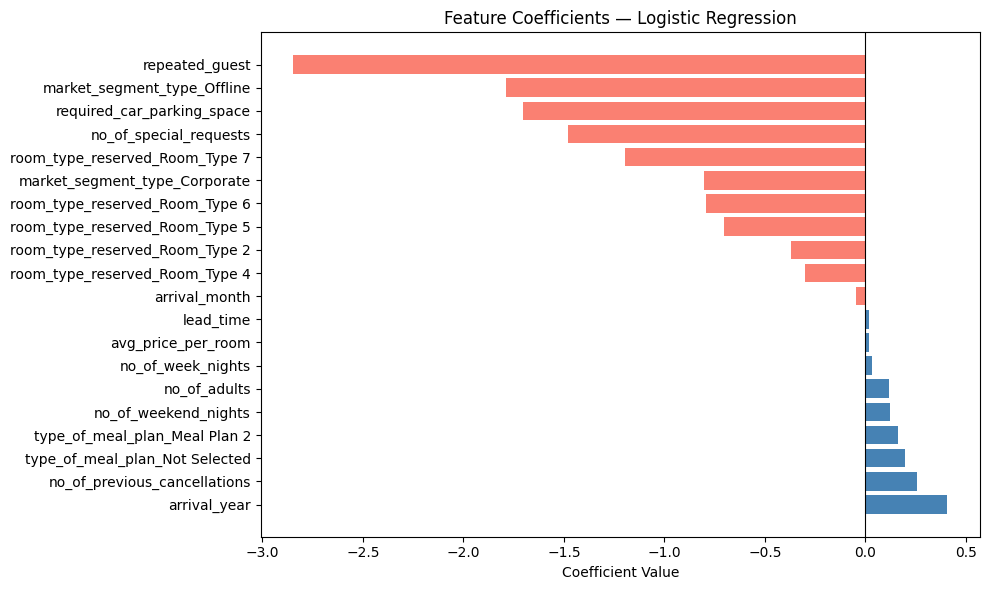

In [54]:
# Feature Coefficient Chart
coef_df = pd.DataFrame({
    'Feature': final_logit.params.index,
    'Coefficient': final_logit.params.values
}).sort_values('Coefficient', ascending=False)
coef_df = coef_df[coef_df['Feature'] != 'const']

plt.figure(figsize=(10, 6))
colors = ['salmon' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients — Logistic Regression')
plt.tight_layout()
plt.show()

## 11. Summary & Conclusion

This project built a **Logistic Regression** model to predict hotel booking cancellations.

**Key Steps:**
- Loaded Hotel Reservations dataset (~36,000 rows, 19 columns)
- Dropped Booking_ID and encoded target variable numerically
- One-hot encoded all categorical features; converted booleans to integers; cast all to float64
- Built full logistic regression model and selected significant features (p ≤ 0.05)
- Evaluated using Confusion Matrix, Accuracy, Classification Report, ROC-AUC, and Feature Coefficients

**The model successfully identifies key drivers of hotel booking cancellations.**